<a href="https://colab.research.google.com/github/GuilhermeOrnellas/exerc-cio-Pandas./blob/main/Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    palette="muted"
)

np.random.seed(101)
n = 300

dados = {
    'idade': np.random.normal(35, 10, n).astype(int),
    'plano': np.random.choice(
        ['Gratuito', 'Básico', 'Pro'],
        n,
        p=[0.5, 0.3, 0.2]
    ),
    'tempo_uso_horas': np.random.uniform(1, 50, n),
    'bugs_reportados': np.random.poisson(2, n),
    'satisfacao': np.random.randint(1, 11, n)
}

df_sistema = pd.DataFrame(dados)

# Regras de negócio
df_sistema.loc[
    df_sistema['plano'] == 'Pro',
    'tempo_uso_horas'
] += 15

df_sistema.loc[
    df_sistema['plano'] == 'Pro',
    'satisfacao'
] += 2

df_sistema['satisfacao'] = (
    df_sistema['satisfacao']
    - (df_sistema['bugs_reportados'] * 0.5)
)

df_sistema['satisfacao'] = (
    df_sistema['satisfacao']
    .clip(1, 10)
    .astype(int)
)

df_sistema['idade'] = (
    df_sistema['idade']
    .clip(18, 70)
)

questão 1

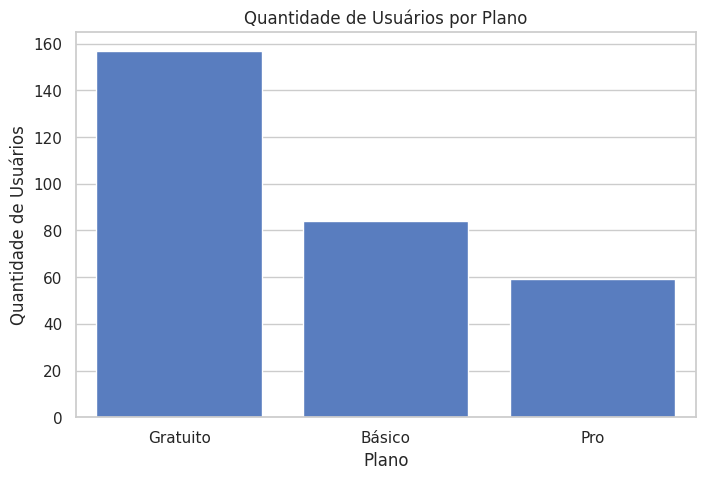

In [2]:
ordem_planos = df_sistema['plano'].value_counts().index

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_sistema,
    x='plano',
    order=ordem_planos
)

plt.title('Quantidade de Usuários por Plano')
plt.xlabel('Plano')
plt.ylabel('Quantidade de Usuários')

plt.show()


questão 2

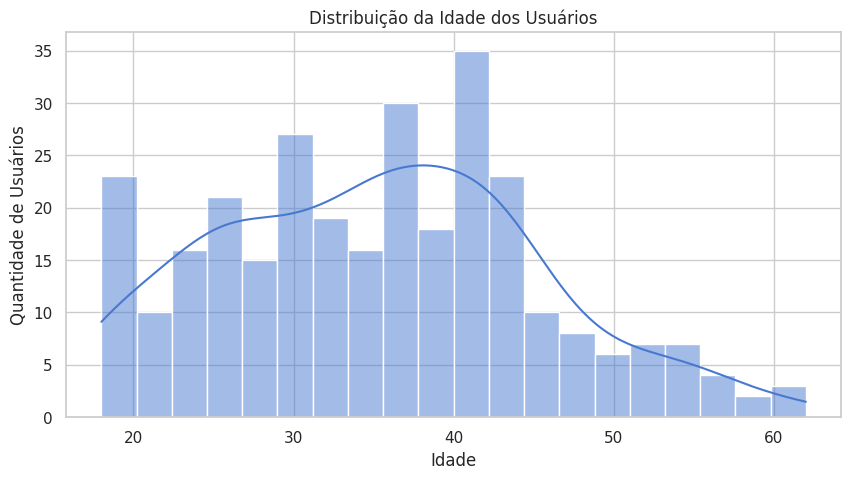

In [3]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_sistema,
    x='idade',
    bins=20,
    kde=True
)

plt.title('Distribuição da Idade dos Usuários')
plt.xlabel('Idade')
plt.ylabel('Quantidade de Usuários')

plt.show()


questão 3

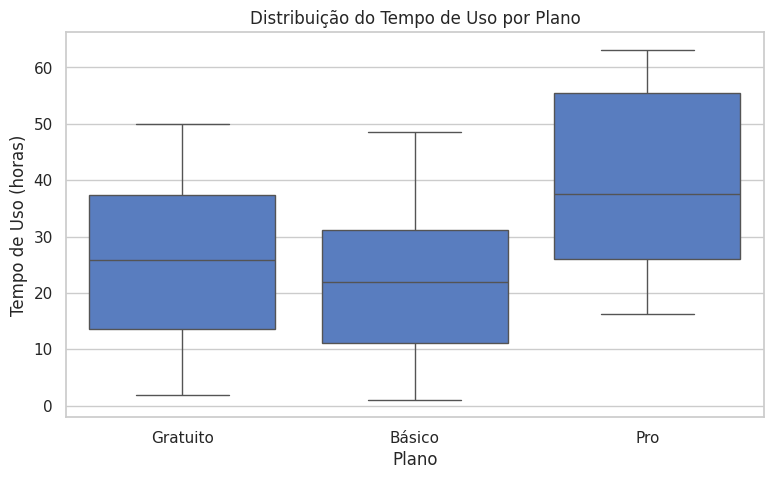

In [4]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_sistema,
    x='plano',
    y='tempo_uso_horas',
    order=['Gratuito', 'Básico', 'Pro']
)

plt.title('Distribuição do Tempo de Uso por Plano')
plt.xlabel('Plano')
plt.ylabel('Tempo de Uso (horas)')

plt.show()


questão 4

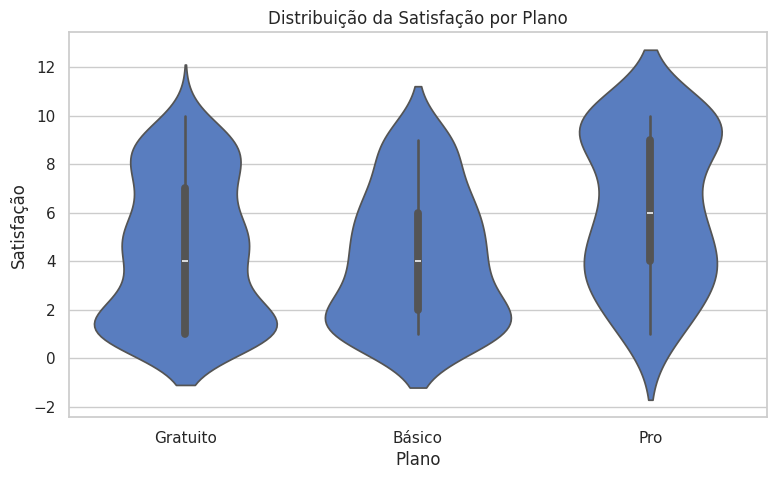

In [5]:
plt.figure(figsize=(9, 5))

sns.violinplot(
    data=df_sistema,
    x='plano',
    y='satisfacao',
    order=['Gratuito', 'Básico', 'Pro']
)

plt.title('Distribuição da Satisfação por Plano')
plt.xlabel('Plano')
plt.ylabel('Satisfação')

plt.show()

questão 5

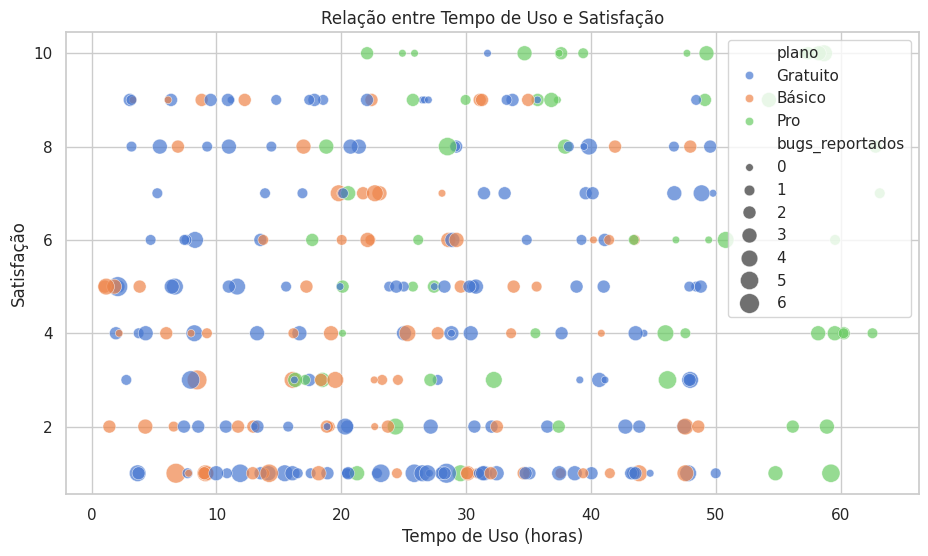

In [6]:
plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=df_sistema,
    x='tempo_uso_horas',
    y='satisfacao',
    hue='plano',
    size='bugs_reportados',
    sizes=(30, 200),
    alpha=0.7
)

plt.title('Relação entre Tempo de Uso e Satisfação')
plt.xlabel('Tempo de Uso (horas)')
plt.ylabel('Satisfação')

plt.show()

questão 6

Matriz de Correlação de Pearson:
                    idade  tempo_uso_horas  bugs_reportados  satisfacao
idade            1.000000        -0.041905         0.059112   -0.046303
tempo_uso_horas -0.041905         1.000000        -0.034809    0.081600
bugs_reportados  0.059112        -0.034809         1.000000   -0.219174
satisfacao      -0.046303         0.081600        -0.219174    1.000000


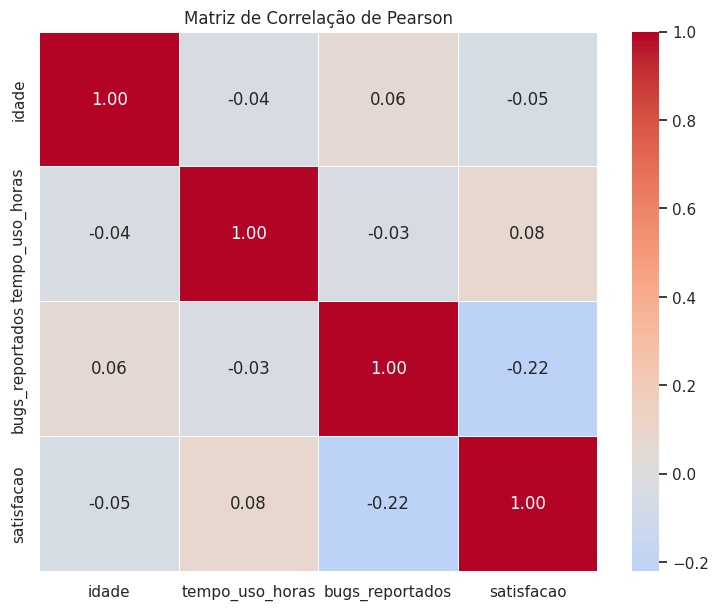

In [7]:
df_numerico = df_sistema.select_dtypes(
    include=np.number
)

matriz_correlacao = df_numerico.corr(
    method='pearson'
)

print('Matriz de Correlação de Pearson:')
print(matriz_correlacao)

plt.figure(figsize=(9, 7))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Matriz de Correlação de Pearson')

plt.show()

questão 7

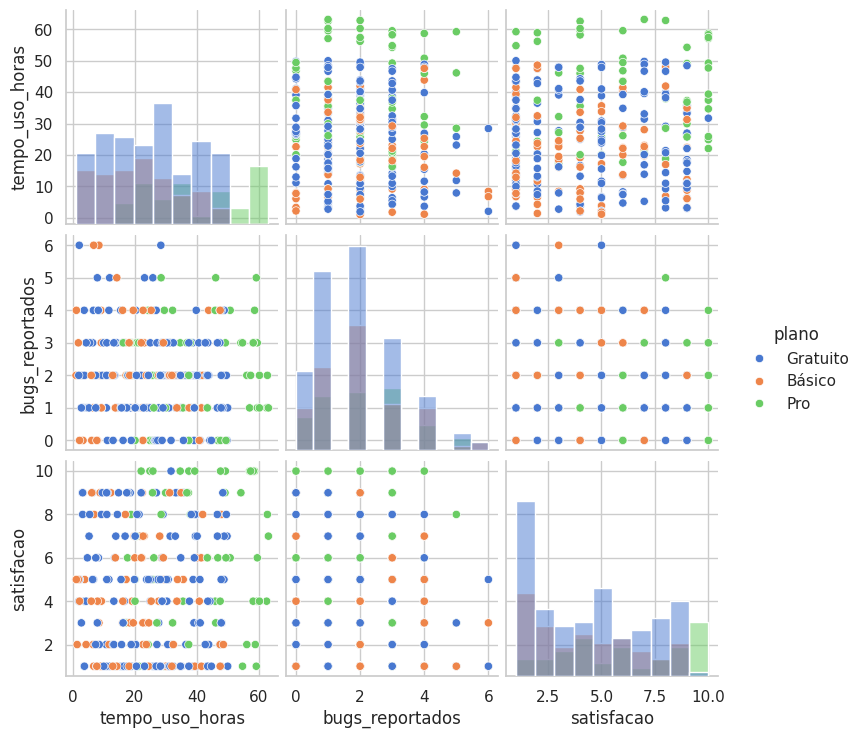

In [8]:
sns.pairplot(
    df_sistema,
    vars=[
        'tempo_uso_horas',
        'bugs_reportados',
        'satisfacao'
    ],
    hue='plano',
    diag_kind='hist'
)

plt.show()